# MLX Autoencoder simple example
- from [Intro to Autoencoders](https://www.tensorflow.org/tutorials/generative/autoencoder)

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import logging

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score

logging.basicConfig()

/Users/ricky/VSCODE/timeseries_autoencoder/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
sys.path.append(os.path.join('..','src'))
from timeseries_autoencoder.utils import plot_reconstruction
from timeseries_autoencoder.mlx_models.autoencoders import FixedLengthFullyConnectedAutoEncoder

from timeseries_autoencoder import data
data.logger.setLevel(logging.DEBUG)

## Data download

In [3]:
train_data, test_data, train_labels, test_labels = data.get_tensorflow_ECG5000()

DEBUG:timeseries_autoencoder.data:creating temp file in ../data/temp/ECG5000
DEBUG:timeseries_autoencoder.data:file ../data/temp/ECG5000/ecg.csv already exists
DEBUG:timeseries_autoencoder.data:reading ../data/temp/ECG5000/ecg.csv
DEBUG:timeseries_autoencoder.data:modifying labels


## Data normalization

In [4]:
min_val = np.min(train_data)
max_val = np.max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = np.float32(train_data)
test_data = np.float32(test_data)

## Nominal / Anomalous data separation

In [5]:
normal_train_data = train_data[train_labels == 0]
anomalous_train_data = train_data[train_labels == 1]

len(normal_train_data), len(anomalous_train_data)

(2359, 1639)

### Plot a normal vs anomalous ECG

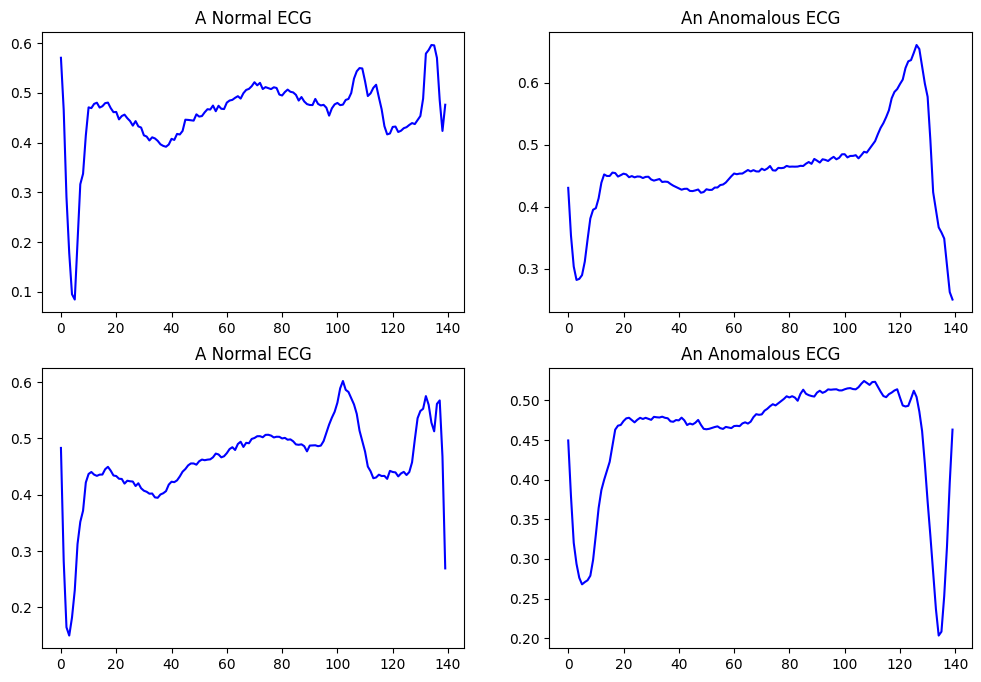

In [6]:
samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):
    plot_reconstruction(normal_train_data[s], axes[s][0]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_train_data[s], axes[s][1]).set_title("An Anomalous ECG")


In [7]:
# split train set to get a validation
validation_fraction = 0.02

rng = np.random.default_rng(123)
index = np.arange(len(normal_train_data))

t = int(validation_fraction * len(normal_train_data))

validation_set = normal_train_data[:t]
train_set = normal_train_data[t:]

assert len(normal_train_data) == len(train_set) + len(validation_set)
print(f'train size: {len(train_set)} - validation size: {len(validation_set)}')

train size: 2312 - validation size: 47


In [8]:
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim


In [9]:
def loss_fn(model, X, y):
    return nn.losses.l1_loss(model(X), y, reduction="mean")

def batch_iterate(batch_size, X, y):
    for s in range(0, y.size, batch_size):
        yield X[s : s + batch_size], y[s : s + batch_size]
        

In [10]:
train_set, validation_set = map(mx.array,[train_set, validation_set])

from functools import partial
import time

learning_rate = 1e-5
num_epochs = 1
batch_size = 256

autoencoder = FixedLengthFullyConnectedAutoEncoder()
mx.eval(autoencoder.parameters())

optimizer = optim.SGD(learning_rate=learning_rate)
loss_and_grad_fn = nn.value_and_grad(autoencoder, loss_fn)

@partial(mx.compile, inputs=autoencoder.state, outputs=autoencoder.state)
def step(X, y):
    loss, grads = loss_and_grad_fn(autoencoder, X, y)
    optimizer.update(autoencoder, grads)
    return loss

@partial(mx.compile, inputs=autoencoder.state)
def eval_fn(X, y):
    return loss_fn(autoencoder, X, y)

for e in range(num_epochs):
    tic = time.perf_counter()
    for X, y in batch_iterate(batch_size, train_set, train_set):
        step(X, y)
        mx.eval(autoencoder.state)
    eval_loss = eval_fn(validation_set, validation_set)
    toc = time.perf_counter()
    print(
        f"Epoch {e}: Validation loss {eval_loss.item():.3f},"
        f" Time {toc - tic:.3f} (s)"
    )

: 